# Airbnb Price Prediction and Insights

In [118]:
#import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [88]:
#Load the dataset
airbnb = pd.read_csv('Airbnb_data - airbnb_data.csv')
airbnb.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


### 1) Data Exploration and Preprocessing 

In [89]:
airbnb.shape

(74111, 29)

we have 74111 rows and 29 columns.

In [91]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73923 non-null

In [92]:
airbnb.describe()

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,7.411100e+04,74111.000000,74111.000000,73911.000000,74111.000000,74111.000000,74111.000000,57389.000000,74020.000000,73980.000000
mean,1.126662e+07,4.782069,3.155146,1.235263,38.445958,-92.397525,20.900568,94.067365,1.265793,1.710868
std,6.081735e+06,0.717394,2.153589,0.582044,3.080167,21.705322,37.828641,7.836556,0.852143,1.254142
min,3.440000e+02,0.000000,1.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000
25%,6.261964e+06,4.317488,2.000000,1.000000,34.127908,-118.342374,1.000000,92.000000,1.000000,1.000000
50%,1.225415e+07,4.709530,2.000000,1.000000,40.662138,-76.996965,6.000000,96.000000,1.000000,1.000000
75%,1.640226e+07,5.220356,4.000000,1.000000,40.746096,-73.954660,23.000000,100.000000,1.000000,2.000000
max,2.123090e+07,7.600402,16.000000,8.000000,42.390437,-70.985047,605.000000,100.000000,10.000000,18.000000


In [93]:
# checking missing values
airbnb.isnull().sum().sort_values(ascending=False)

host_response_rate        18299
review_scores_rating      16722
first_review              15864
last_review               15827
thumbnail_url              8216
neighbourhood              6872
zipcode                     968
bathrooms                   200
host_identity_verified      188
host_since                  188
host_has_profile_pic        188
beds                        131
bedrooms                     91
description                   0
name                          0
property_type                 0
room_type                     0
amenities                     0
number_of_reviews             0
accommodates                  0
longitude                     0
city                          0
latitude                      0
bed_type                      0
instant_bookable              0
cancellation_policy           0
cleaning_fee                  0
log_price                     0
id                            0
dtype: int64

We have multiple columns which have missing values host_response_rate has the highest missing values followed by review_scores_rating, first_review, last_review, thumbnail_url and neighbourhood.

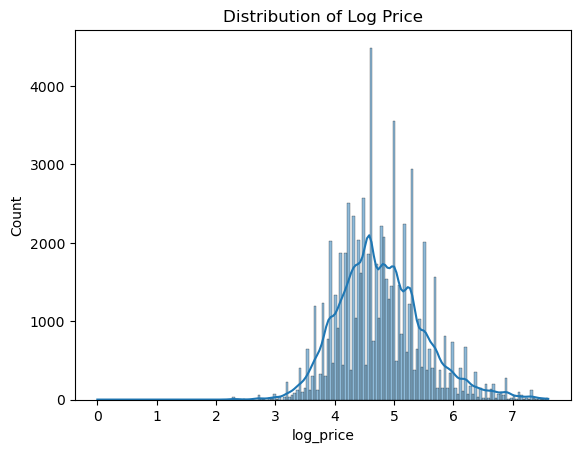

In [94]:
# Analyze target variable
import seaborn as sns
sns.histplot(airbnb['log_price'], kde=True)
plt.title('Distribution of Log Price')
plt.show()

The log-transformed price shows an approximately normal distribution with reduced skewness, indicating that log transformation is effective and suitable for regression modeling.

In [95]:
numerical_column= [ 'accommodates','bathrooms','bedrooms','beds',
    'number_of_reviews','review_scores_rating',
    'latitude','longitude']
airbnb[numerical_column].describe()

,accommodates,bathrooms,bedrooms,beds,number_of_reviews,review_scores_rating,latitude,longitude
count,74111.000000,73911.000000,74020.000000,73980.000000,74111.000000,57389.000000,74111.000000,74111.000000
mean,3.155146,1.235263,1.265793,1.710868,20.900568,94.067365,38.445958,-92.397525
std,2.153589,0.582044,0.852143,1.254142,37.828641,7.836556,3.080167,21.705322
min,1.000000,0.000000,0.000000,0.000000,0.000000,20.000000,33.338905,-122.511500
25%,2.000000,1.000000,1.000000,1.000000,1.000000,92.000000,34.127908,-118.342374
50%,2.000000,1.000000,1.000000,1.000000,6.000000,96.000000,40.662138,-76.996965
75%,4.000000,1.000000,1.000000,2.000000,23.000000,100.000000,40.746096,-73.954660
max,16.000000,8.000000,10.000000,18.000000,605.000000,100.000000,42.390437,-70.985047


<function matplotlib.pyplot.show(close=None, block=None)>

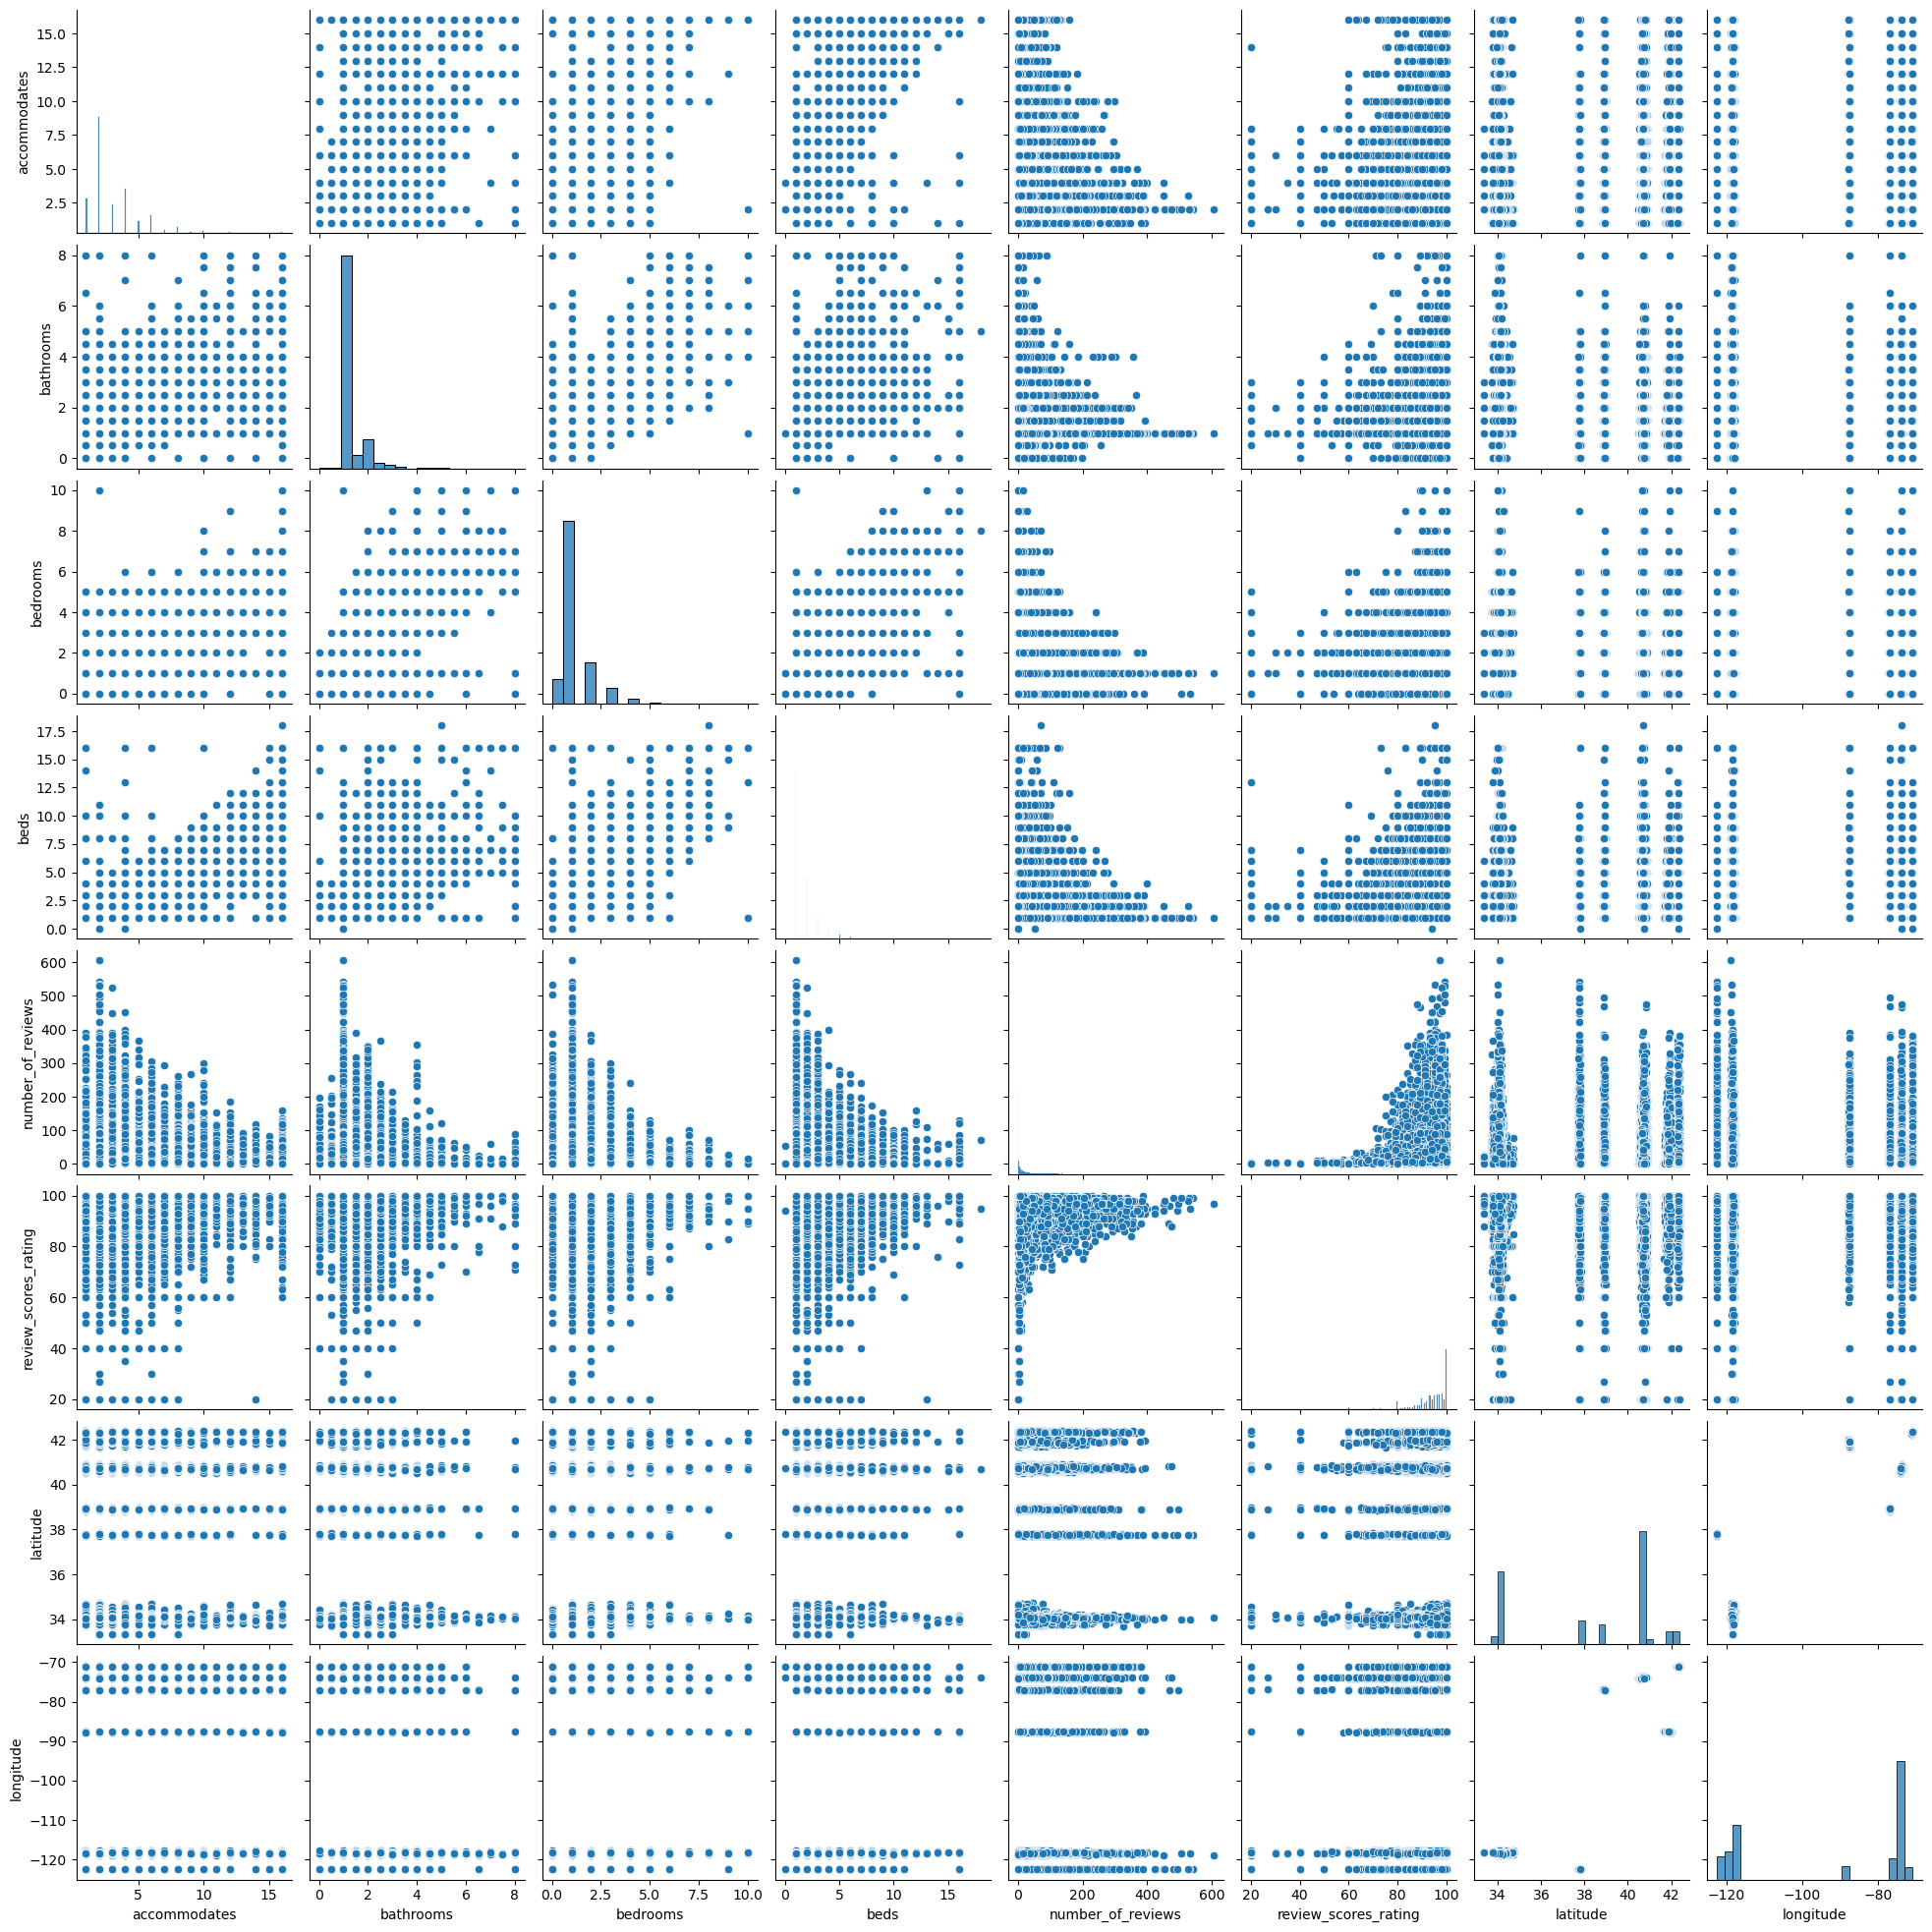

In [96]:
# Pairplot to visualize relationship between variables
sns.pairplot(airbnb[numerical_column])
plt.show

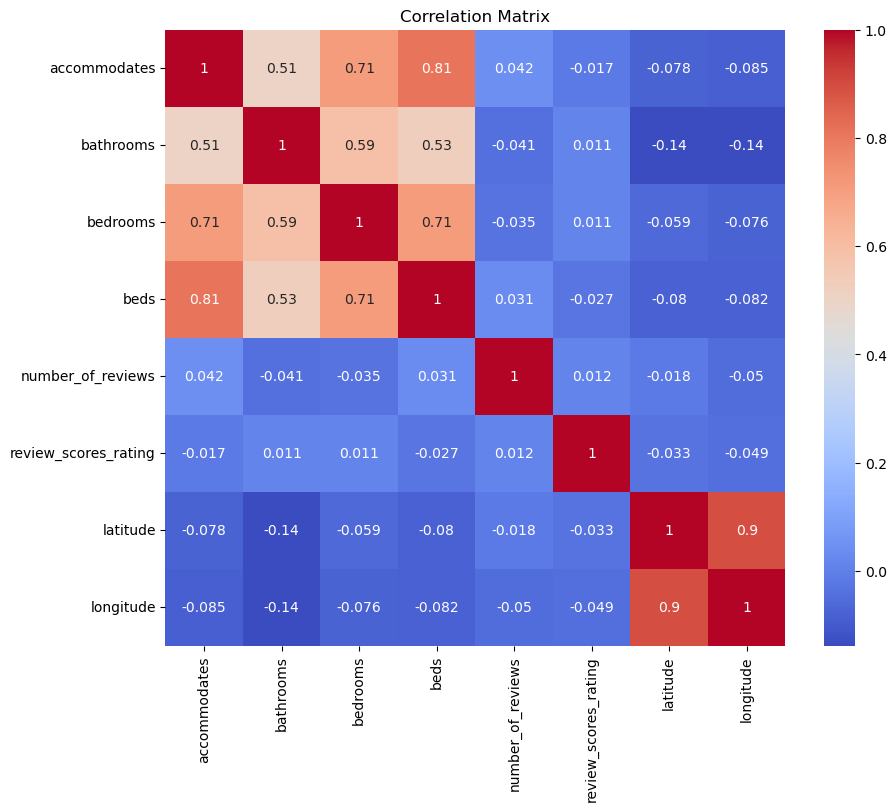

In [98]:
# Correlation matrix
correlation_matrix = airbnb[numerical_column].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot = True, cmap ='coolwarm')
plt.title('Correlation Matrix')
plt.show()

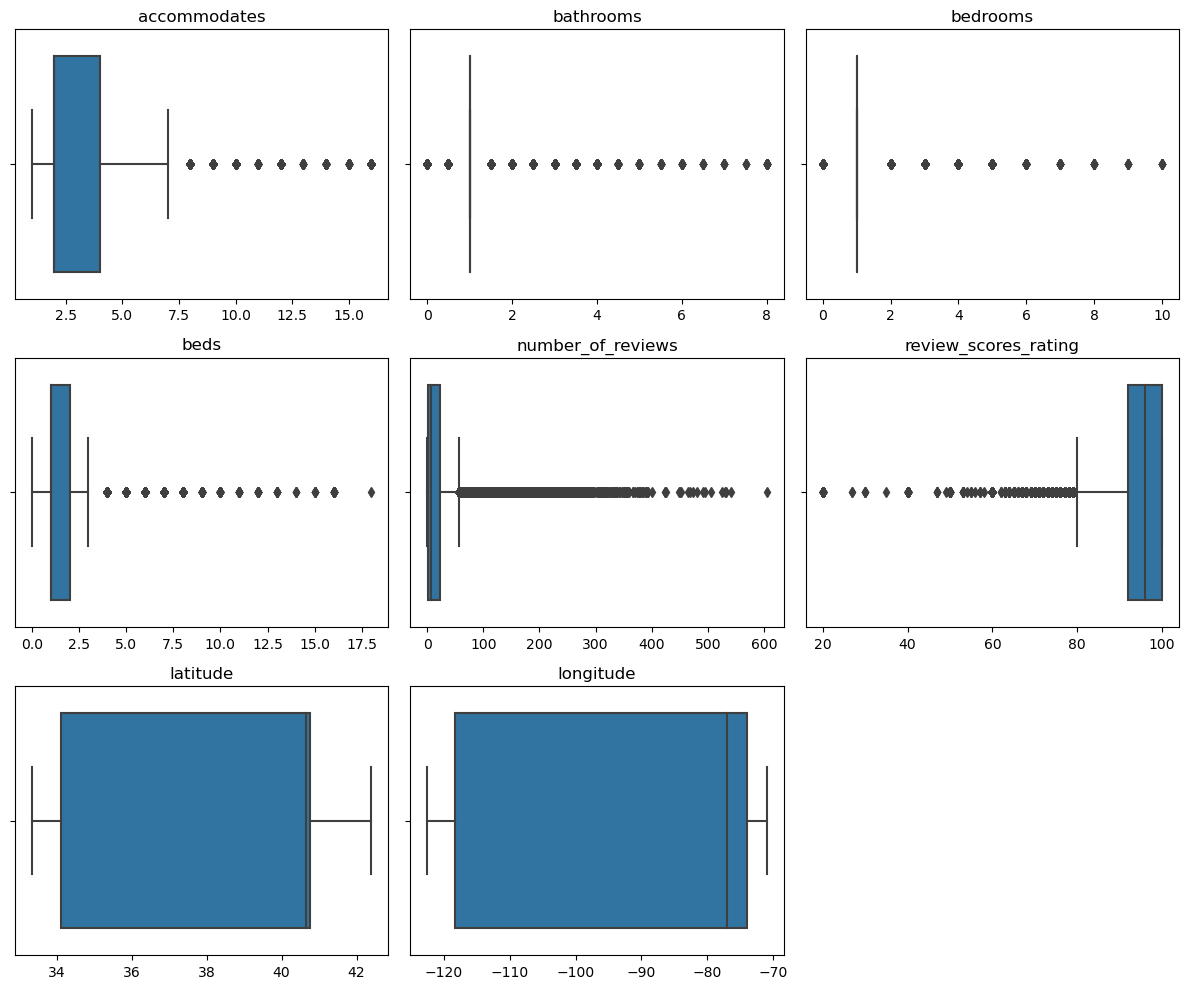

In [99]:
# Outlier Detection
plt.figure(figsize = (12,10))
for i, column in enumerate(numerical_column):
    plt.subplot(3,3, i+1)
    sns.boxplot(x=airbnb[column])
    plt.xlabel("")
    plt.title(column)
plt.tight_layout()
plt.show()


The boxplots reveal that most numerical variables exhibit right-skewed distributions with several outliers. This is expected in Airbnb data due to variation in listing size, popularity, and location. Review scores show limited variability and are concentrated at higher values, while latitude and longitude represent geographical spread rather than traditional outliers.

In [123]:
#Feature Engineering
airbnb['amenities_count'] = airbnb['amenities'].apply(
    lambda x: len(str(x).split(','))
)


In [157]:
X = airbnb[
    [
        'accommodates',
        'bathrooms',
        'bedrooms',
        'beds',
        'number_of_reviews',
        'review_scores_rating',
        'amenities_count',
        'cleaning_fee'
    ]
]

y = airbnb['log_price']

   

In [158]:

print(X.isna().sum())



accommodates            0
bathrooms               0
bedrooms                0
beds                    0
number_of_reviews       0
review_scores_rating    0
amenities_count         0
cleaning_fee            0
dtype: int64


In [159]:
# Convert all columns to numeric
X = X.apply(pd.to_numeric, errors='coerce')



In [160]:
# Fill missing values
X = X.fillna(X.median())


In [161]:
print(X.isna().sum())


accommodates            0
bathrooms               0
bedrooms                0
beds                    0
number_of_reviews       0
review_scores_rating    0
amenities_count         0
cleaning_fee            0
dtype: int64


The dataset was explored to understand data types, missing values, and distributions. Several numerical and categorical features influencing Airbnb prices were identified. Missing values were handled using median and mode imputation. Date features were transformed into meaningful numerical variables. Categorical variables were encoded using one-hot encoding, and boolean features were converted to numeric format. Irrelevant and high-cardinality text features were removed. Finally, feature scaling was applied to prepare the dataset for regression modeling.

### 2) Model Development

In [162]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state =42)

In [169]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In this phase, a regression model was developed to predict Airbnb listing prices using key features such as accommodation capacity, number of bedrooms and beds, number of reviews, and geographical location. The log-transformed price was used as the target variable to reduce skewness and improve model performance. The dataset was split into training and testing sets, and feature scaling was applied to ensure uniform contribution of predictors. A Linear Regression model was trained to learn the relationship between input features and listing prices.

### 3) Model Evaluation


In [164]:
#Make predictions
y_pred = model.predict(X_test)


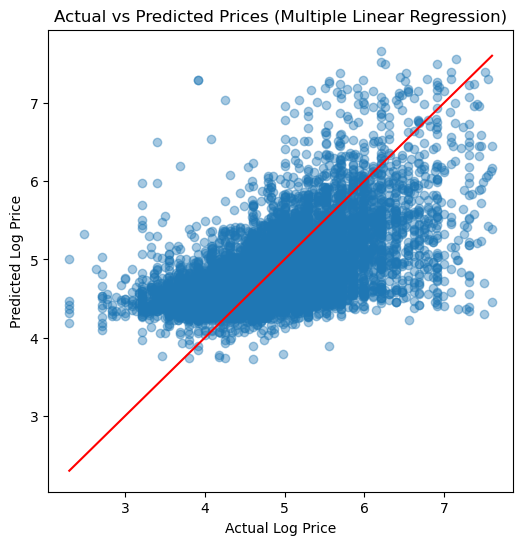

In [165]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted Prices (Multiple Linear Regression)")
plt.show()


The scatter plot shows a strong alignment between actual and predicted values, indicating good model performance.

In [166]:
#calculating evaluation matrix
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.4456837069448971
Root Mean Squared Error (RMSE): 0.5802137420840103
R² Score: 0.3446933716193923


In [167]:
# Display the coefficients of the model
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients)

                      Coefficient
accommodates             0.176009
bathrooms                0.069810
bedrooms                 0.118823
beds                    -0.069019
number_of_reviews       -0.000933
review_scores_rating     0.008803
amenities_count          0.005122
cleaning_fee             0.010905


The performance of the regression model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score. MAE and RMSE were used to measure the average prediction error, while the R² score assessed how well the model explained the variance in listing prices. The evaluation results indicate that the model provides reasonable predictions and captures the key factors influencing Airbnb pricing.

In [168]:
accommodates = int(input("Enter accommodates: "))
bathrooms = float(input("Enter bathrooms: "))
bedrooms = float(input("Enter bedrooms: "))
beds = float(input("Enter beds: "))
number_of_reviews = int(input("Enter number of reviews: "))
review_scores_rating = float(input("Enter review score rating: "))
amenities_count = int(input("Enter amenities count: "))
cleaning_fee = int(input("Cleaning fee? (1 = Yes, 0 = No): "))

user_input = np.array([[
    accommodates,
    bathrooms,
    bedrooms,
    beds,
    number_of_reviews,
    review_scores_rating,
    amenities_count,
    cleaning_fee
]])

predicted_log_price = model.predict(user_input)
predicted_price = np.exp(predicted_log_price)

print(f"Predicted Airbnb Price: {predicted_price[0]:.2f}")


Enter accommodates: 1
Enter bathrooms: 2
Enter bedrooms: 3
Enter beds: 2
Enter number of reviews: 45
Enter review score rating: 24
Enter amenities count: 6
Cleaning fee? (1 = Yes, 0 = No): 1
Predicted Airbnb Price: 51.51
